In [3]:
import json
import boto3
import pandas as pd
import numpy as np
import awswrangler as wr
from sqlalchemy import create_engine

import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [4]:
client = boto3.client("secretsmanager", region_name="us-east-1")
secret = client.get_secret_value(SecretId="itam/rds/northwind/credentials")
creds = json.loads(secret["SecretString"])

{
    "username": creds["username"],
    "dbname": creds.get("dbname"),
    "port": creds.get("port")
}

{'username': 'itam', 'dbname': 'flights', 'port': '5432'}

In [5]:
RDS_REPLICA_ENDPOINT = "itam-northwind-replica-995371347105.ciheg4as0flj.us-east-1.rds.amazonaws.com"
DB_NAME = "flights"

engine = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{RDS_REPLICA_ENDPOINT}:{creds['port']}/{DB_NAME}"
)

In [6]:
query_p1 = """
SELECT
    origin_airport,
    destination_airport,
    COUNT(*) AS total_flights
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_flights DESC
LIMIT 10;
"""

df_p1 = pd.read_sql(query_p1, engine)
df_p1

,origin_airport,destination_airport,total_flights
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


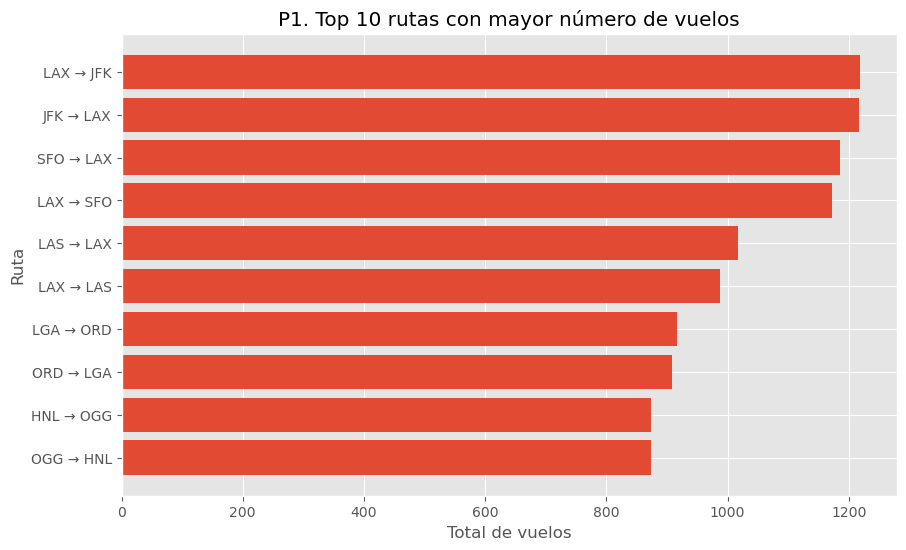

In [9]:
df_p1["route"] = df_p1["origin_airport"] + " → " + df_p1["destination_airport"]

plt.figure(figsize=(10, 6))
plt.barh(df_p1["route"], df_p1["total_flights"])
plt.xlabel("Total de vuelos")
plt.ylabel("Ruta")
plt.title("P1. Top 10 rutas con mayor número de vuelos")
plt.gca().invert_yaxis()
plt.show()

In [10]:
query_p2 = """
SELECT
    airline,
    COUNT(*) AS total_flights,
    SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END) AS total_cancelled,
    100.0 * SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END) / COUNT(*) AS cancelled_pct
FROM flights
GROUP BY airline
ORDER BY cancelled_pct DESC, total_flights DESC
LIMIT 5;
"""

df_p2 = pd.read_sql(query_p2, engine)
df_p2

,airline,total_flights,total_cancelled,cancelled_pct
0,MQ,31896,3136,9.831954
1,B6,23062,1479,6.413147
2,EV,52965,2523,4.763523
3,US,35591,1268,3.562698
4,UA,40873,1424,3.483963


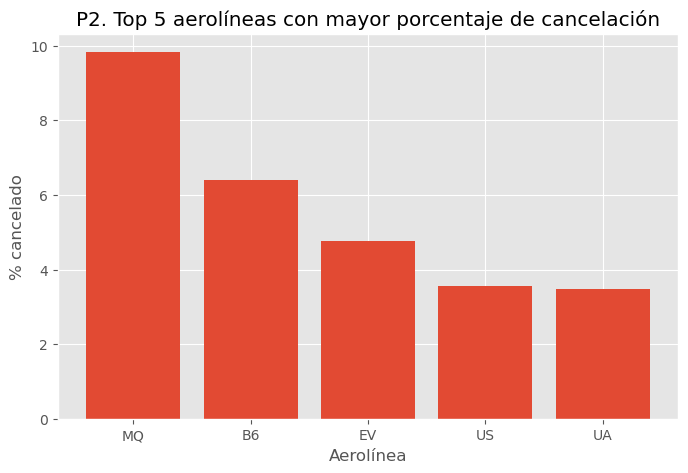

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(df_p2["airline"], df_p2["cancelled_pct"])
plt.xlabel("Aerolínea")
plt.ylabel("% cancelado")
plt.title("P2. Top 5 aerolíneas con mayor porcentaje de cancelación")
plt.show()

In [12]:
query_p3 = """
SELECT
    cancellation_reason,
    COUNT(*) AS total_cancelled
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total_cancelled DESC;
"""

df_p3 = pd.read_sql(query_p3, engine)
df_p3

,cancellation_reason,total_cancelled
0,B,10630
1,A,3230
2,C,2962
3,D,2


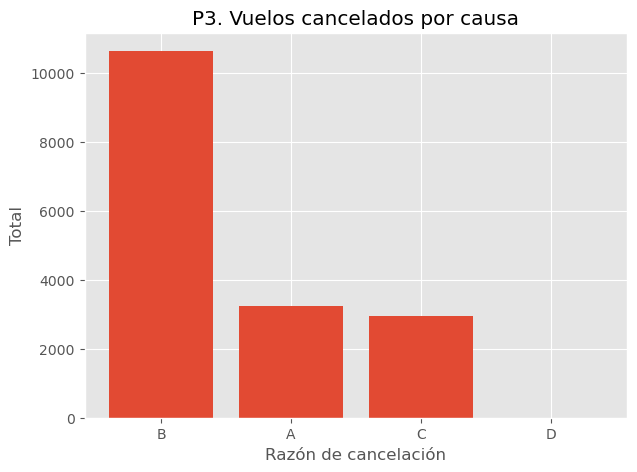

In [13]:
plt.figure(figsize=(7, 5))
plt.bar(df_p3["cancellation_reason"], df_p3["total_cancelled"])
plt.xlabel("Razón de cancelación")
plt.ylabel("Total")
plt.title("P3. Vuelos cancelados por causa")
plt.show()

In [14]:
query_p4 = """
SELECT
    month,
    AVG(departure_delay) AS avg_departure_delay
FROM flights
WHERE cancelled = 0
  AND departure_delay > 0
GROUP BY month
ORDER BY month;
"""

df_p4 = pd.read_sql(query_p4, engine)
df_p4

,month,avg_departure_delay
0,1,32.571225
1,2,42.306487


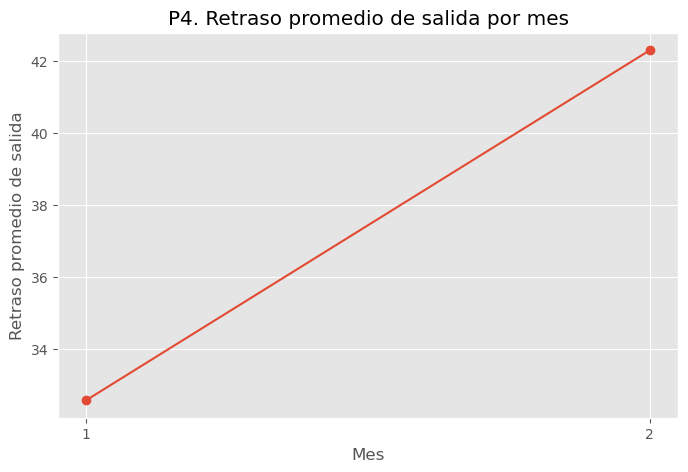

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(df_p4["month"], df_p4["avg_departure_delay"], marker="o")
plt.xlabel("Mes")
plt.ylabel("Retraso promedio de salida")
plt.title("P4. Retraso promedio de salida por mes")
plt.xticks(df_p4["month"])
plt.show()

In [16]:
query_p5 = """
SELECT
    origin_airport,
    SUM(COALESCE(weather_delay, 0)) AS total_weather_delay_minutes
FROM flights
GROUP BY origin_airport
ORDER BY total_weather_delay_minutes DESC
LIMIT 10;
"""

df_p5 = pd.read_sql(query_p5, engine)
df_p5

,origin_airport,total_weather_delay_minutes
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


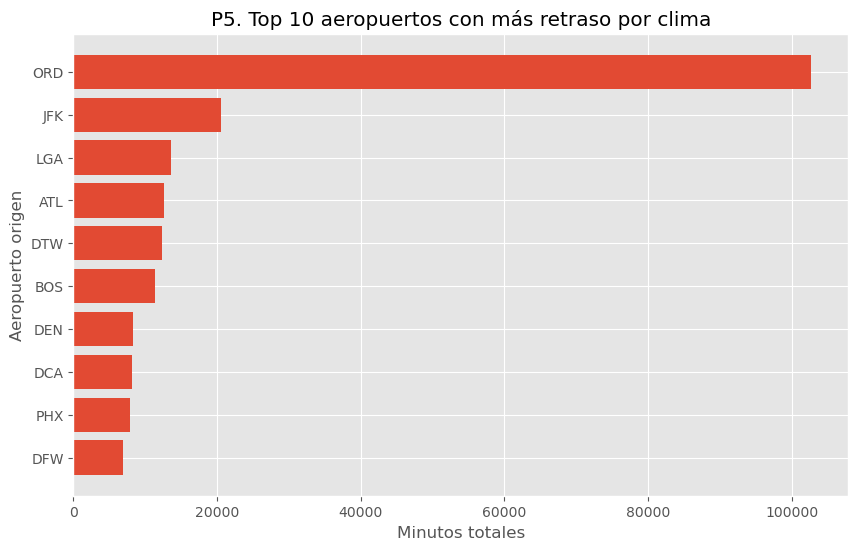

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(df_p5["origin_airport"], df_p5["total_weather_delay_minutes"])
plt.xlabel("Minutos totales")
plt.ylabel("Aeropuerto origen")
plt.title("P5. Top 10 aeropuertos con más retraso por clima")
plt.gca().invert_yaxis()
plt.show()

In [18]:
query_w1 = """
WITH ranked_flights AS (
    SELECT
        airline,
        flight_number,
        origin_airport,
        destination_airport,
        arrival_delay,
        RANK() OVER (
            PARTITION BY airline
            ORDER BY arrival_delay DESC NULLS LAST
        ) AS rnk
    FROM flights
)
SELECT
    airline,
    flight_number,
    origin_airport,
    destination_airport,
    arrival_delay
FROM ranked_flights
WHERE rnk = 1
ORDER BY airline;
"""

df_w1 = pd.read_sql(query_w1, engine)
df_w1

,airline,flight_number,origin_airport,destination_airport,arrival_delay
0,AA,1322,BHM,DFW,1971.0
1,AS,455,LAX,SEA,451.0
2,B6,576,MSY,JFK,502.0
3,DL,1435,MIA,MSP,1174.0
4,EV,2567,SHV,DFW,723.0
5,F9,1256,ORD,MIA,686.0
6,HA,51,JFK,HNL,1013.0
7,MQ,2962,CLL,DFW,788.0
8,NK,728,TPA,ORD,570.0
9,OO,2642,CHO,ORD,953.0


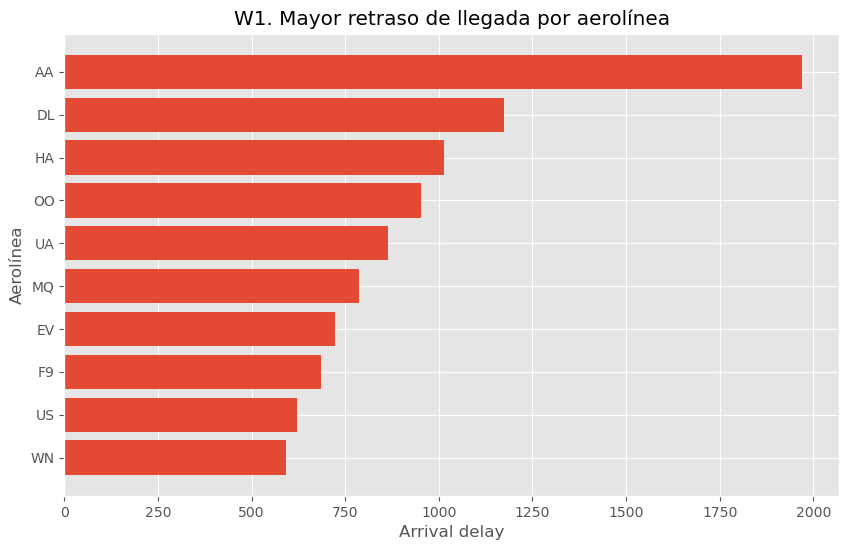

In [19]:
df_w1_plot = df_w1.sort_values("arrival_delay", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(df_w1_plot["airline"], df_w1_plot["arrival_delay"])
plt.xlabel("Arrival delay")
plt.ylabel("Aerolínea")
plt.title("W1. Mayor retraso de llegada por aerolínea")
plt.gca().invert_yaxis()
plt.show()

In [20]:
query_w3 = """
WITH ordered_flights AS (
    SELECT
        year,
        month,
        day,
        origin_airport,
        flight_number,
        airline,
        destination_airport,
        scheduled_departure,
        ROW_NUMBER() OVER (
            PARTITION BY year, month, day, origin_airport
            ORDER BY scheduled_departure ASC
        ) AS rn
    FROM flights
    WHERE year = 2015
      AND month = 1
      AND day = 1
      AND origin_airport = 'LAX'
)
SELECT
    flight_number,
    airline,
    destination_airport,
    scheduled_departure
FROM ordered_flights
WHERE rn <= 5
ORDER BY rn;
"""

df_w3 = pd.read_sql(query_w3, engine)
df_w3

,flight_number,airline,destination_airport,scheduled_departure
0,2336,AA,PBI,10
1,258,AA,MIA,20
2,2013,US,CLT,30
3,1434,DL,MSP,35
4,115,AA,MIA,105


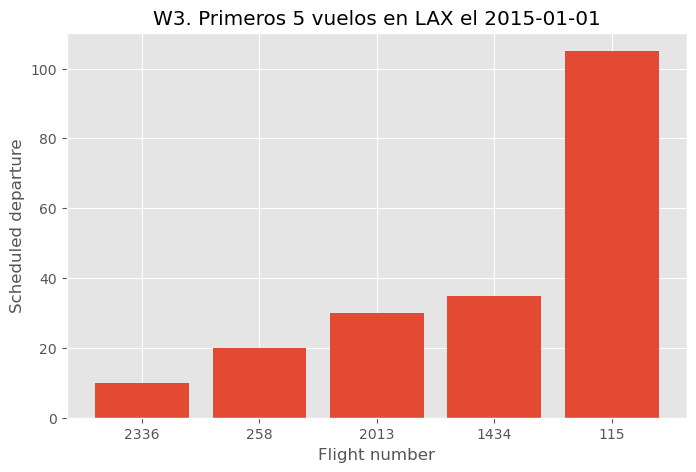

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(df_w3["flight_number"].astype(str), df_w3["scheduled_departure"])
plt.xlabel("Flight number")
plt.ylabel("Scheduled departure")
plt.title("W3. Primeros 5 vuelos en LAX el 2015-01-01")
plt.show()

In [22]:
query_w2 = """
SELECT
    month,
    SUM(total_flights) AS total_flights,
    LAG(SUM(total_flights)) OVER (ORDER BY month) AS prev_month_flights,
    SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month) AS abs_change,
    100.0 * (
        SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month)
    ) / NULLIF(LAG(SUM(total_flights)) OVER (ORDER BY month), 0) AS pct_change
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month;
"""

df_w2 = wr.athena.read_sql_query(
    sql=query_w2,
    database="flights_silver"
)

df_w2

2026-04-16 06:45:49,316	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409956352 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.71gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-16 06:45:50,597	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,prev_month_flights,abs_change,pct_change
0,1,469968,<NA>,<NA>,NaN
1,2,429191,469968,-40777,-8.676548
2,3,504312,429191,75121,17.502930
3,4,485151,504312,-19161,-3.799434
4,5,496993,485151,11842,2.440890
5,6,503897,496993,6904,1.389154
6,7,520718,503897,16821,3.338182
7,8,510536,520718,-10182,-1.955377
8,9,464946,510536,-45590,-8.929831
9,10,486165,464946,21219,4.563756


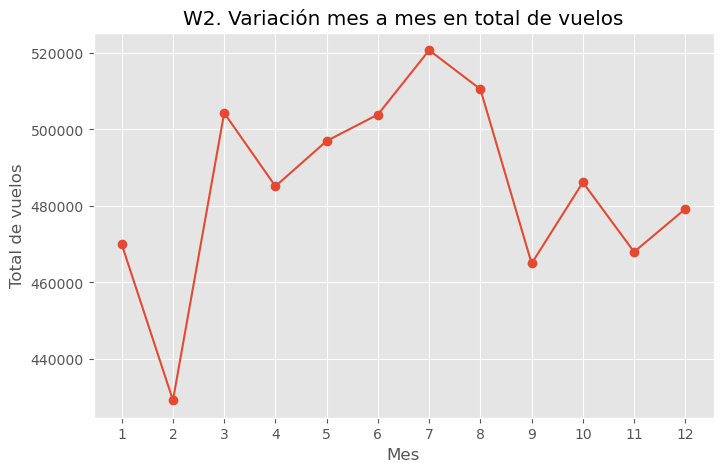

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(df_w2["month"], df_w2["total_flights"], marker="o")
plt.xlabel("Mes")
plt.ylabel("Total de vuelos")
plt.title("W2. Variación mes a mes en total de vuelos")
plt.xticks(df_w2["month"])
plt.show()

In [7]:
query_reg = """
SELECT
    arrival_delay,
    departure_delay,
    distance,
    air_system_delay,
    airline_delay,
    weather_delay,
    late_aircraft_delay,
    security_delay
FROM flights_gold.vuelos_analitica
WHERE cancelled = 0
  AND arrival_delay IS NOT NULL
  AND rand() < 0.02
"""

df_reg = wr.athena.read_sql_query(
    sql=query_reg,
    database="flights_gold"
)

df_reg.head()

2026-04-16 07:02:08,814	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409956352 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.72gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-16 07:02:10,104	INFO worker.py:1852 -- Started a local Ray instance.


,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
0,159.0,133.0,1085,159.0,0.0,0.0,0.0,0.0
1,6.0,-1.0,574,NaN,NaN,NaN,NaN,NaN
2,-35.0,8.0,1839,NaN,NaN,NaN,NaN,NaN
3,223.0,212.0,812,11.0,0.0,212.0,0.0,0.0
4,8.0,3.0,2917,NaN,NaN,NaN,NaN,NaN


In [11]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

In [13]:
df_reg.dtypes

arrival_delay          float64
departure_delay        float64
distance                 Int64
air_system_delay       float64
airline_delay          float64
weather_delay          float64
late_aircraft_delay    float64
security_delay         float64
dtype: object

In [14]:
cols_reg = [
    "arrival_delay",
    "departure_delay",
    "distance",
    "air_system_delay",
    "airline_delay",
    "weather_delay",
    "late_aircraft_delay",
    "security_delay",
]

df_reg[cols_reg] = df_reg[cols_reg].apply(pd.to_numeric, errors="coerce")

In [15]:
df_reg = df_reg.replace([np.inf, -np.inf], np.nan)
df_reg = df_reg.dropna(subset=cols_reg)

df_reg.shape

(21181, 8)

In [16]:
y = df_reg["arrival_delay"].astype(float)

X = df_reg[
    [
        "departure_delay",
        "distance",
        "air_system_delay",
        "airline_delay",
        "weather_delay",
        "late_aircraft_delay",
        "security_delay",
    ]
].astype(float)

In [17]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          arrival_delay   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.718e+32
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:06:09   Log-Likelihood:             5.8326e+05
No. Observations:               21181   AIC:                        -1.167e+06
Df Residuals:                   21173   BIC:                        -1.166e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -1.354e-14   3

In [18]:
y_hat = model.predict(X_const)
residuals = y - y_hat

r2 = model.rsquared
rmse = np.sqrt(np.mean((y - y_hat) ** 2))

print("R²:", r2)
print("RMSE:", rmse)

R²: 1.0
RMSE: 2.658517440038483e-13


In [19]:
coef_df = pd.DataFrame({
    "variable": model.params.index,
    "coef": model.params.values,
    "ci_low": model.conf_int()[0].values,
    "ci_high": model.conf_int()[1].values,
})

coef_df = coef_df[coef_df["variable"] != "const"].sort_values("coef")
coef_df

,variable,coef,ci_low,ci_high
2,distance,-1.262553e-16,-1.321968e-16,-1.203139e-16
1,departure_delay,1.630640e-15,1.406823e-15,1.854457e-15
7,security_delay,1.000000e+00,1.000000e+00,1.000000e+00
5,weather_delay,1.000000e+00,1.000000e+00,1.000000e+00
6,late_aircraft_delay,1.000000e+00,1.000000e+00,1.000000e+00
4,airline_delay,1.000000e+00,1.000000e+00,1.000000e+00
3,air_system_delay,1.000000e+00,1.000000e+00,1.000000e+00


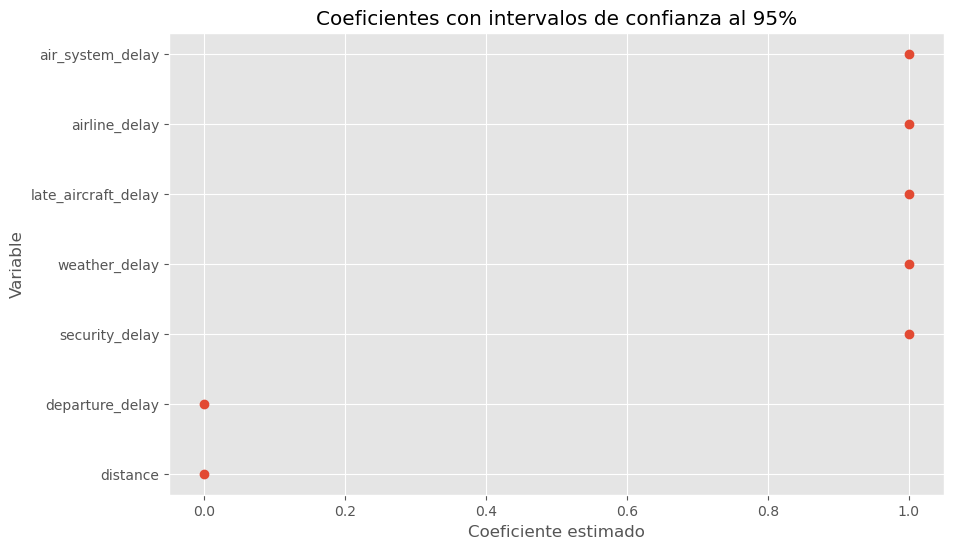

In [20]:
plt.figure(figsize=(10, 6))
plt.errorbar(
    x=coef_df["coef"],
    y=coef_df["variable"],
    xerr=[
        coef_df["coef"] - coef_df["ci_low"],
        coef_df["ci_high"] - coef_df["coef"]
    ],
    fmt="o"
)
plt.xlabel("Coeficiente estimado")
plt.ylabel("Variable")
plt.title("Coeficientes con intervalos de confianza al 95%")
plt.show()

In [21]:
plot_df = pd.DataFrame({
    "y": y,
    "y_hat": y_hat,
    "residuals": residuals
}).sample(n=min(5000, len(y)), random_state=27)

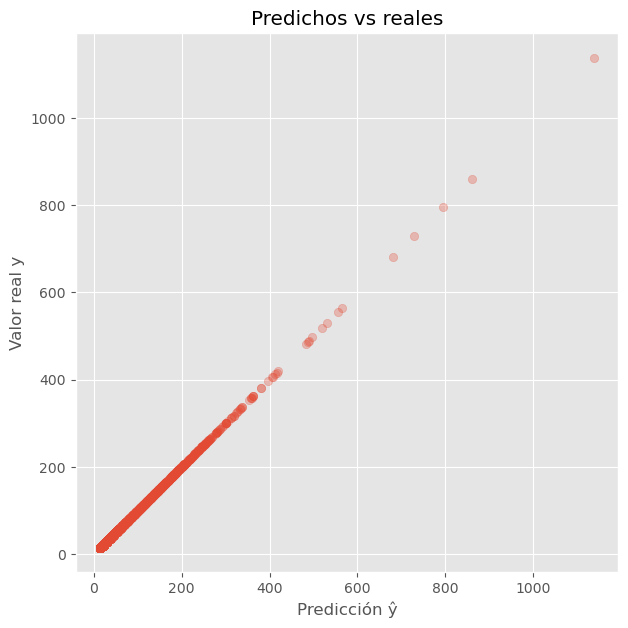

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(plot_df["y_hat"], plot_df["y"], alpha=0.3)
plt.xlabel("Predicción ŷ")
plt.ylabel("Valor real y")
plt.title("Predichos vs reales")
plt.show()

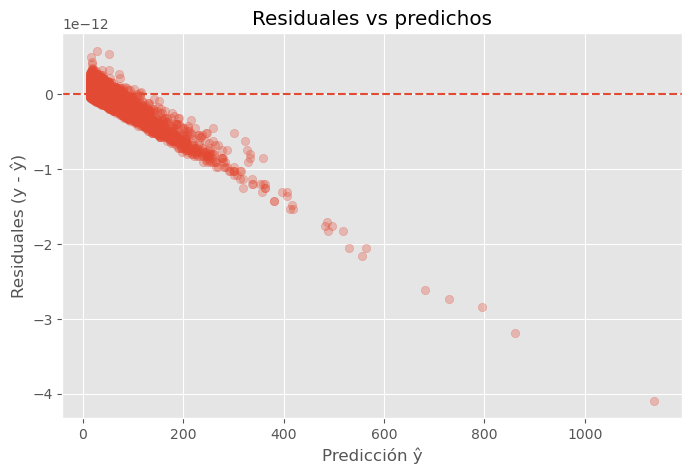

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["y_hat"], plot_df["residuals"], alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción ŷ")
plt.ylabel("Residuales (y - ŷ)")
plt.title("Residuales vs predichos")
plt.show()

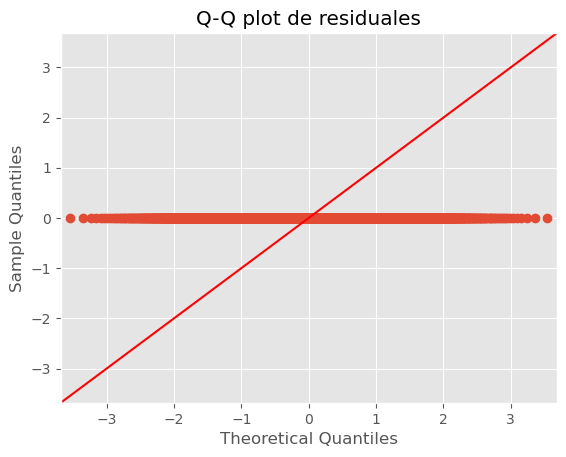

In [24]:
sm.qqplot(residuals.sample(n=min(5000, len(residuals)), random_state=27), line="45")
plt.title("Q-Q plot de residuales")
plt.show()

El modelo presenta un ajuste prácticamente perfecto (R² = 1.00 y RMSE ≈ 0), y en la gráfica de valores predichos vs. reales los puntos se alinean casi exactamente sobre la diagonal, lo que indica que las variables incluidas reproducen casi por completo el retraso de llegada. En la gráfica de coeficientes, las variables con mayor impacto son air_system_delay, airline_delay, weather_delay, late_aircraft_delay y security_delay, todas con coeficientes cercanos a 1, mientras que distance y departure_delay tienen efectos mucho menores. Sin embargo, los diagnósticos muestran que esto ocurre porque varias variables explicativas son componentes directos del propio arrival_delay, por lo que existe multicolinealidad severa. La gráfica de residuales vs. predichos no muestra dispersión aleatoria alrededor de cero, sino residuales extremadamente pequeños y con estructura, y el Q-Q plot evidencia una fuerte desviación respecto a la normalidad. En conjunto, estos resultados sugieren que, aunque el ajuste predictivo es muy bueno, los supuestos clásicos de la regresión lineal no se cumplen de forma ideal.

In [27]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta
from sklearn.metrics import mean_absolute_error

In [28]:
query_ts = """
SELECT
    month,
    SUM(total_flights) AS total_flights
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month
"""

df_ts = wr.athena.read_sql_query(
    sql=query_ts,
    database="flights_silver"
)

df_ts

,month,total_flights
0,1,469968
1,2,429191
2,3,504312
3,4,485151
4,5,496993
5,6,503897
6,7,520718
7,8,510536
8,9,464946
9,10,486165


In [29]:
df_ts["ds"] = pd.to_datetime({
    "year": [2015] * len(df_ts),
    "month": df_ts["month"],
    "day": [1] * len(df_ts)
})

df_sf = pd.DataFrame({
    "unique_id": "flights",
    "ds": df_ts["ds"],
    "y": df_ts["total_flights"]
})

df_sf

,unique_id,ds,y
0,flights,2015-01-01,469968
1,flights,2015-02-01,429191
2,flights,2015-03-01,504312
3,flights,2015-04-01,485151
4,flights,2015-05-01,496993
5,flights,2015-06-01,503897
6,flights,2015-07-01,520718
7,flights,2015-08-01,510536
8,flights,2015-09-01,464946
9,flights,2015-10-01,486165


In [30]:
train_df = df_sf[df_sf["ds"] < "2015-10-01"].copy()
test_df = df_sf[df_sf["ds"] >= "2015-10-01"].copy()

train_df

,unique_id,ds,y
0,flights,2015-01-01,469968
1,flights,2015-02-01,429191
2,flights,2015-03-01,504312
3,flights,2015-04-01,485151
4,flights,2015-05-01,496993
5,flights,2015-06-01,503897
6,flights,2015-07-01,520718
7,flights,2015-08-01,510536
8,flights,2015-09-01,464946


In [31]:
test_df

,unique_id,ds,y
9,flights,2015-10-01,486165
10,flights,2015-11-01,467972
11,flights,2015-12-01,479230


In [32]:
models = [
    AutoETS(season_length=12),
    AutoARIMA(season_length=12),
    AutoTheta(season_length=12),
]

sf = StatsForecast(
    models=models,
    freq="MS"
)

In [33]:
forecast_df = sf.forecast(
    df=train_df,
    h=9,
    level=[90]
)

forecast_df

,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,flights,2015-10-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496523.56250,465489.46875,535667.4375
1,flights,2015-11-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.25000,460775.68750,525887.6250
2,flights,2015-12-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.96875,453725.75000,529276.8750
3,flights,2016-01-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496525.68750,460986.34375,525810.5000
4,flights,2016-02-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496526.40625,466634.28125,533010.1250
5,flights,2016-03-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496527.12500,463863.09375,530507.7500
6,flights,2016-04-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496527.81250,460121.37500,532280.3125
7,flights,2016-05-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496528.53125,461351.53125,532693.5625
8,flights,2016-06-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496529.25000,459872.06250,532316.2500


In [34]:
forecast_test = forecast_df.iloc[:3].copy()
forecast_future = forecast_df.iloc[3:].copy()

forecast_test

,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,flights,2015-10-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496523.56250,465489.46875,535667.4375
1,flights,2015-11-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.25000,460775.68750,525887.6250
2,flights,2015-12-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.96875,453725.75000,529276.8750


In [35]:
forecast_future

,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
3,flights,2016-01-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496525.68750,460986.34375,525810.5000
4,flights,2016-02-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496526.40625,466634.28125,533010.1250
5,flights,2016-03-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496527.12500,463863.09375,530507.7500
6,flights,2016-04-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496527.81250,460121.37500,532280.3125
7,flights,2016-05-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496528.53125,461351.53125,532693.5625
8,flights,2016-06-01,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496529.25000,459872.06250,532316.2500


In [37]:
eval_df = test_df[["unique_id", "ds", "y"]].merge(
    forecast_test,
    on=["unique_id", "ds"],
    how="left"
)

eval_df

,unique_id,ds,y,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,flights,2015-10-01,486165,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496523.56250,465489.46875,535667.4375
1,flights,2015-11-01,467972,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.25000,460775.68750,525887.6250
2,flights,2015-12-01,479230,487319.90625,428025.15625,546614.625,487301.34375,440427.09375,534175.5625,496524.96875,453725.75000,529276.8750


In [38]:
mae_results = pd.DataFrame({
    "model": ["AutoETS", "AutoARIMA", "AutoTheta"],
    "MAE": [
        mean_absolute_error(eval_df["y"], eval_df["AutoETS"]),
        mean_absolute_error(eval_df["y"], eval_df["AutoARIMA"]),
        mean_absolute_error(eval_df["y"], eval_df["AutoTheta"]),
    ]
})

mae_results = mae_results.sort_values("MAE")
mae_results

,model,MAE
1,AutoARIMA,9512.343750
0,AutoETS,9530.906250
2,AutoTheta,18735.259766


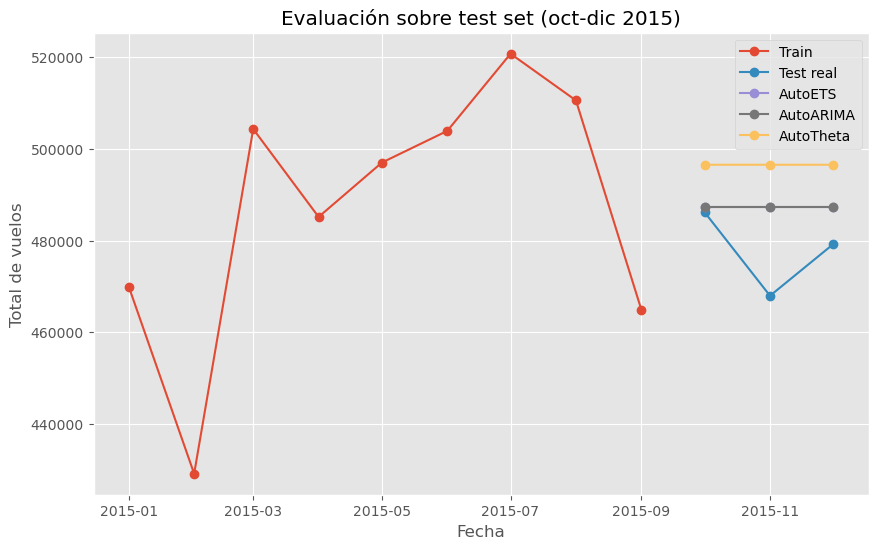

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(train_df["ds"], train_df["y"], marker="o", label="Train")
plt.plot(test_df["ds"], test_df["y"], marker="o", label="Test real")

plt.plot(forecast_test["ds"], forecast_test["AutoETS"], marker="o", label="AutoETS")
plt.plot(forecast_test["ds"], forecast_test["AutoARIMA"], marker="o", label="AutoARIMA")
plt.plot(forecast_test["ds"], forecast_test["AutoTheta"], marker="o", label="AutoTheta")

plt.xlabel("Fecha")
plt.ylabel("Total de vuelos")
plt.title("Evaluación sobre test set (oct-dic 2015)")
plt.legend()
plt.show()

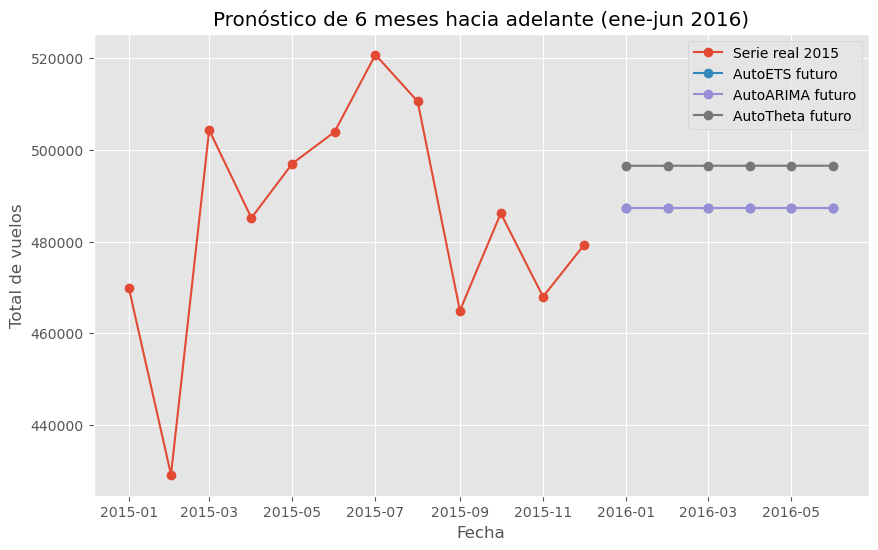

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(df_sf["ds"], df_sf["y"], marker="o", label="Serie real 2015")

plt.plot(forecast_future["ds"], forecast_future["AutoETS"], marker="o", label="AutoETS futuro")
plt.plot(forecast_future["ds"], forecast_future["AutoARIMA"], marker="o", label="AutoARIMA futuro")
plt.plot(forecast_future["ds"], forecast_future["AutoTheta"], marker="o", label="AutoTheta futuro")

plt.xlabel("Fecha")
plt.ylabel("Total de vuelos")
plt.title("Pronóstico de 6 meses hacia adelante (ene-jun 2016)")
plt.legend()
plt.show()

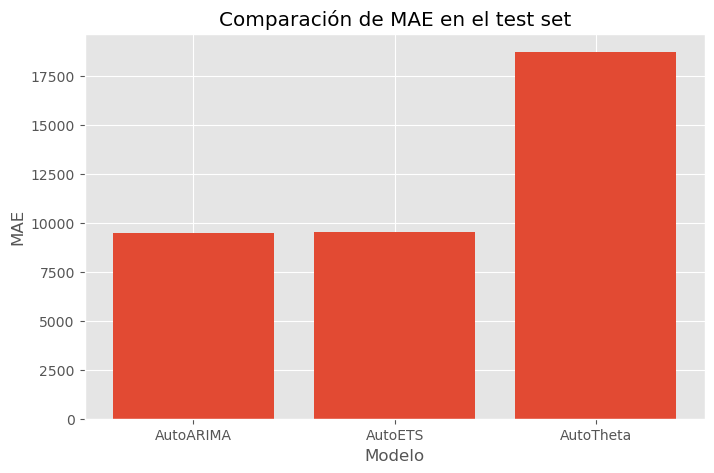

In [41]:
plt.figure(figsize=(8, 5))
plt.bar(mae_results["model"], mae_results["MAE"])
plt.xlabel("Modelo")
plt.ylabel("MAE")
plt.title("Comparación de MAE en el test set")
plt.show()

In [43]:
best_model = mae_results.iloc[0]["model"]
best_mae = mae_results.iloc[0]["MAE"]

print("Mejor modelo:", best_model)
print("Mejor MAE:", best_mae)
print(mae_results)

Mejor modelo: AutoARIMA
Mejor MAE: 9512.34375
       model           MAE
1  AutoARIMA   9512.343750
0    AutoETS   9530.906250
2  AutoTheta  18735.259766


Entre los tres modelos probados, AutoARIMA mostró el mejor desempeño en el conjunto de prueba, con el MAE más bajo (9512.343750), ligeramente mejor que AutoETS y claramente mejor que AutoTheta. En la gráfica de evaluación sobre oct–dic 2015, tanto AutoARIMA como AutoETS siguen razonablemente el nivel de la serie real, aunque ninguno captura por completo la caída observada en noviembre. Los pronósticos hacia adelante para ene–jun 2016 son casi planos, lo que sugiere que con solo un año de datos y únicamente 9 meses de entrenamiento los modelos tienen información limitada para identificar una estacionalidad anual robusta. En consecuencia, los intervalos de confianza reflejan una incertidumbre relativamente alta y muestran que la certeza del pronóstico es limitada cuando se dispone de tan poca historia temporal.